# Feature Engineering and Polynomial Regression


In [114]:
import numpy as np
import matplotlib.pyplot as plt

In [136]:
x = np.arange(0, 20, 1)
y = 1 + x**2
y = y.reshape(-1,1)
X = np.column_stack([x, x**2,x**3])
# print(f"X : {X}")
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
# print(f"X : {X}")


## Cost Function

In [137]:
def compute_cost(X, y, w, b):
    prediction = X@w + b
    error = prediction - y

    m = X.shape[0]
    # print(f"error : {error}")
    cost = (1/(2*m))* np.sum(error**2)
    return cost
    
    

In [143]:
def gradient_descent(X, y, w, b, alpha, iteration):

    m = X.shape[0]
    cost_history = []

    for i in range(iteration):
        prediction = X @ w + b
        error = prediction - y

        dj_dw = (1 / m) * (X.T @ error) 

        dj_db = (1 / m) * np.sum(error)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            cost_history.append(cost)
            print(f"iteration : {i}, cost : {round(cost, 4)}")

    return w, b

In [148]:
alpha = 0.5
iteration = 10000
w_init = np.zeros((3,1))
b_init = 0
opt_w, opt_b = gradient_descent(X, y, w_init, b_init, alpha, iteration)
print(f"w : {opt_w}, b : {opt_b}")


iteration : 0, cost : 3277.0597
iteration : 100, cost : 4.8059
iteration : 200, cost : 4.2105
iteration : 300, cost : 3.6893
iteration : 400, cost : 3.2326
iteration : 500, cost : 2.8325
iteration : 600, cost : 2.4819
iteration : 700, cost : 2.1747
iteration : 800, cost : 1.9055
iteration : 900, cost : 1.6696
iteration : 1000, cost : 1.4629
iteration : 1100, cost : 1.2819
iteration : 1200, cost : 1.1232
iteration : 1300, cost : 0.9842
iteration : 1400, cost : 0.8623
iteration : 1500, cost : 0.7556
iteration : 1600, cost : 0.6621
iteration : 1700, cost : 0.5801
iteration : 1800, cost : 0.5083
iteration : 1900, cost : 0.4454
iteration : 2000, cost : 0.3903
iteration : 2100, cost : 0.3419
iteration : 2200, cost : 0.2996
iteration : 2300, cost : 0.2625
iteration : 2400, cost : 0.23
iteration : 2500, cost : 0.2016
iteration : 2600, cost : 0.1766
iteration : 2700, cost : 0.1547
iteration : 2800, cost : 0.1356
iteration : 2900, cost : 0.1188
iteration : 3000, cost : 0.1041
iteration : 3100, c

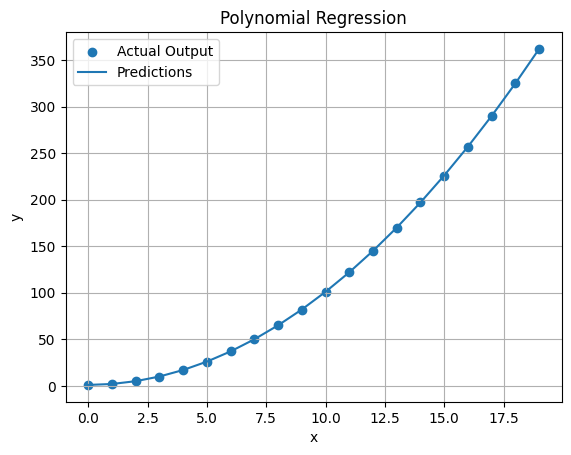

In [150]:

predictions = X @ opt_w + opt_b

plt.scatter(x, y.flatten(), label="Actual Output")

plt.plot(x, predictions.flatten(), label="Predictions")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Polynomial Regression")

plt.grid(True)

plt.legend()

plt.show()